# Module 3 — DR Severity Classification
## Data Understanding & Exploratory Data Analysis

**SIH 2026 — Problem Statement 26038**

This notebook performs the initial inspection and exploratory analysis of the diabetic retinopathy dataset before preprocessing and model training.

### Objectives
- Verify the Python/PyTorch environment
- Inspect dataset structure and metadata
- Analyze DR class distribution
- Check data quality
- Inspect image properties
- Visualize representative retinal images
- Identify potential duplicates
- Produce a final dataset summary

In [21]:
import sys
import platform
import torch

print("=" * 60)
print("ENVIRONMENT INFORMATION")
print("=" * 60)

print(f"Python       : {sys.version.split()[0]}")
print(f"Platform     : {platform.system()} {platform.release()}")
print(f"PyTorch      : {torch.__version__}")
print(f"CUDA version : {torch.version.cuda}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(
        f"VRAM         : "
        f"{torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB"
    )
else:
    print("GPU          : Not available")

ENVIRONMENT INFORMATION
Python       : 3.11.6
Platform     : Windows 10
PyTorch      : 2.7.0+cu128
CUDA version : 12.8
CUDA available: True
GPU          : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM         : 6.00 GB


In [22]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, UnidentifiedImageError

from sklearn.model_selection import train_test_split

In [23]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Random seed set to {SEED}")

Random seed set to 42


In [24]:
# ============================================================
# DATASET PATHS
# ============================================================

DATASET_DIR = Path(r"C:\Users\Arnav Sachdeva\Documents\Data\images")
CSV_PATH = Path(r"C:\Users\Arnav Sachdeva\Documents\Data\labels.csv")

print("Dataset directory:")
print(DATASET_DIR)

print("\nCSV file:")
print(CSV_PATH)

Dataset directory:
C:\Users\Arnav Sachdeva\Documents\Data\images

CSV file:
C:\Users\Arnav Sachdeva\Documents\Data\labels.csv


In [25]:
print("=" * 60)
print("PATH VERIFICATION")
print("=" * 60)

print(f"Dataset directory exists : {DATASET_DIR.exists()}")
print(f"CSV file exists          : {CSV_PATH.exists()}")

if DATASET_DIR.exists():
    print(f"Dataset directory       : {DATASET_DIR.resolve()}")

if CSV_PATH.exists():
    print(f"CSV file                : {CSV_PATH.resolve()}")

PATH VERIFICATION
Dataset directory exists : True
CSV file exists          : True
Dataset directory       : C:\Users\Arnav Sachdeva\Documents\Data\images
CSV file                : C:\Users\Arnav Sachdeva\Documents\Data\labels.csv


In [26]:
df = pd.read_csv(CSV_PATH)

print("=" * 60)
print("DATASET METADATA")
print("=" * 60)

print(f"Number of rows    : {len(df):,}")
print(f"Number of columns : {len(df.columns)}")

print("\nFirst 5 rows:")
display(df.head())

DATASET METADATA
Number of rows    : 4,178
Number of columns : 2

First 5 rows:


,id_code,diagnosis
0,train_IDRiD_001,3
1,train_IDRiD_002,3
2,train_IDRiD_003,2
3,train_IDRiD_004,3
4,train_IDRiD_005,4


In [27]:
print("=" * 60)
print("COLUMN INFORMATION")
print("=" * 60)

print("\nColumns:")
for column in df.columns:
    print(f"  - {column}")

print("\nData types:")
display(df.dtypes)

print("\nDataset information:")
df.info()

COLUMN INFORMATION

Columns:
  - id_code
  - diagnosis

Data types:


id_code      object
diagnosis     int64
dtype: object


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4178 entries, 0 to 4177
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id_code    4178 non-null   object
 1   diagnosis  4178 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 65.4+ KB


In [28]:
print("=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

missing = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": (missing / len(df) * 100).round(2)
})

display(missing_summary)

print(f"\nTotal missing values: {df.isnull().sum().sum()}")

MISSING VALUE ANALYSIS


,Missing Values,Missing Percentage
id_code,0,0.0
diagnosis,0,0.0



Total missing values: 0


In [29]:
LABEL_COLUMN = "diagnosis"

print("=" * 60)
print("DR LABEL ANALYSIS")
print("=" * 60)

print("Unique labels:")
print(sorted(df[LABEL_COLUMN].dropna().unique()))

print("\nLabel counts:")
display(df[LABEL_COLUMN].value_counts(dropna=False).sort_index())

DR LABEL ANALYSIS
Unique labels:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Label counts:


diagnosis
0    1973
1     395
2    1167
3     286
4     357
Name: count, dtype: int64

In [30]:
class_counts = (
    df[LABEL_COLUMN]
    .value_counts()
    .sort_index()
)

class_percentages = (
    df[LABEL_COLUMN]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

class_summary = pd.DataFrame({
    "Image Count": class_counts,
    "Percentage": class_percentages.round(2)
})

print("=" * 60)
print("DR CLASS DISTRIBUTION")
print("=" * 60)

display(class_summary)

DR CLASS DISTRIBUTION


,Image Count,Percentage
diagnosis,,
0,1973,47.22
1,395,9.45
2,1167,27.93
3,286,6.85
4,357,8.54


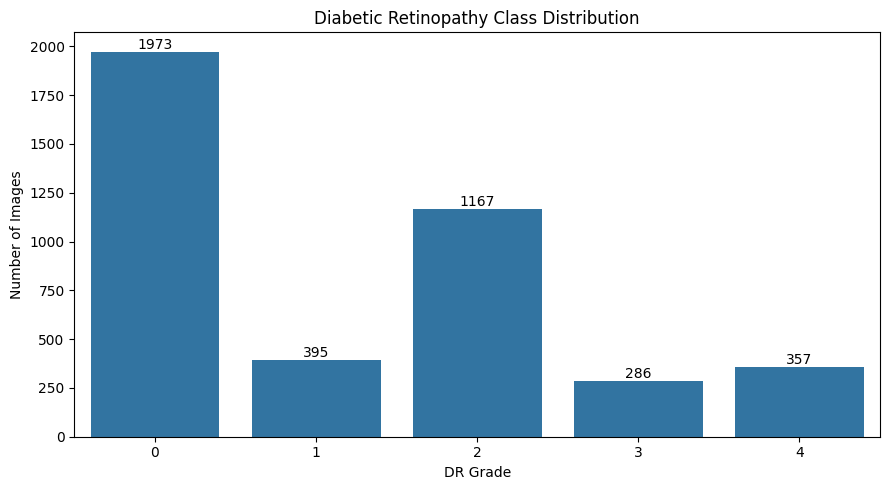

In [31]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=class_summary.index.astype(str),
    y=class_summary["Image Count"]
)

plt.title("Diabetic Retinopathy Class Distribution")
plt.xlabel("DR Grade")
plt.ylabel("Number of Images")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [32]:
largest_class = class_counts.max()
smallest_class = class_counts.min()

largest_grade = class_counts.idxmax()
smallest_grade = class_counts.idxmin()

imbalance_ratio = largest_class / smallest_class

print("=" * 60)
print("CLASS IMBALANCE ANALYSIS")
print("=" * 60)

print(f"Largest class : Grade {largest_grade} ({largest_class:,} images)")
print(f"Smallest class: Grade {smallest_grade} ({smallest_class:,} images)")
print(f"Imbalance ratio: {imbalance_ratio:.2f} : 1")

CLASS IMBALANCE ANALYSIS
Largest class : Grade 0 (1,973 images)
Smallest class: Grade 3 (286 images)
Imbalance ratio: 6.90 : 1


In [33]:
print("=" * 60)
print("DATASET IMAGE DIRECTORY INSPECTION")
print("=" * 60)

# Show the first 20 files in the image directory
image_files = [
    p for p in DATASET_DIR.iterdir()
    if p.is_file()
]

print(f"Total files found in image directory: {len(image_files):,}")

print("\nFirst 20 files:")
for file in image_files[:20]:
    print(f"  {file.name}")

DATASET IMAGE DIRECTORY INSPECTION
Total files found in image directory: 4,178

First 20 files:
  aptos_000c1434d8d7.png
  aptos_001639a390f0.png
  aptos_0024cdab0c1e.png
  aptos_002c21358ce6.png
  aptos_005b95c28852.png
  aptos_0083ee8054ee.png
  aptos_0097f532ac9f.png
  aptos_00a8624548a9.png
  aptos_00b74780d31d.png
  aptos_00cb6555d108.png
  aptos_00cc2b75cddd.png
  aptos_00e4ddff966a.png
  aptos_00f6c1be5a33.png
  aptos_0104b032c141.png
  aptos_0124dffecf29.png
  aptos_0125fbd2e791.png
  aptos_012a242ac6ff.png
  aptos_014508ccb9cb.png
  aptos_0151781fe50b.png
  aptos_0161338f53cc.png


In [34]:
print("=" * 60)
print("IMAGE FILE EXTENSIONS")
print("=" * 60)

extensions = Counter(
    file.suffix.lower()
    for file in image_files
)

for extension, count in extensions.most_common():
    print(f"{extension or '[no extension]':10} : {count:,}")

IMAGE FILE EXTENSIONS
.png       : 3,662
.jpg       : 516


In [35]:
print("=" * 60)
print("IMAGE ↔ LABEL MAPPING DIAGNOSTIC")
print("=" * 60)

# ------------------------------------------------------------
# 1. Define the actual CSV columns
# ------------------------------------------------------------

IMAGE_COLUMN = "id_code"
LABEL_COLUMN = "diagnosis"


# ------------------------------------------------------------
# 2. Find all image files
# ------------------------------------------------------------

all_image_files = [
    p for p in DATASET_DIR.iterdir()
    if p.is_file()
]


# ------------------------------------------------------------
# 3. Create image lookup
#    Filename stem is used, so .png/.jpg does not matter
# ------------------------------------------------------------

image_lookup = {
    p.stem: p
    for p in all_image_files
}


# ------------------------------------------------------------
# 4. Match CSV IDs with actual image files
# ------------------------------------------------------------

df["image_path"] = (
    df[IMAGE_COLUMN]
    .astype(str)
    .map(image_lookup)
)

df["file_exists"] = df["image_path"].notna()


# ------------------------------------------------------------
# 5. Display mapping statistics
# ------------------------------------------------------------

print(f"CSV records      : {len(df):,}")
print(f"Images in folder : {len(all_image_files):,}")
print(f"Matched          : {df['file_exists'].sum():,}")
print(f"Not matched      : {(~df['file_exists']).sum():,}")


# ------------------------------------------------------------
# 6. Inspect matched records
# ------------------------------------------------------------

matched = df[df["file_exists"]]

print("\n" + "=" * 60)
print("MATCHED IMAGE ID EXAMPLES")
print("=" * 60)

display(
    matched[
        [IMAGE_COLUMN, LABEL_COLUMN, "image_path"]
    ].head(10)
)


# ------------------------------------------------------------
# 7. Inspect unmatched records
# ------------------------------------------------------------

unmatched = df[~df["file_exists"]]

print("\n" + "=" * 60)
print("UNMATCHED IMAGE ID EXAMPLES")
print("=" * 60)

if len(unmatched) > 0:
    display(
        unmatched[
            [IMAGE_COLUMN, LABEL_COLUMN]
        ].head(20)
    )
else:
    print("No unmatched images found.")

IMAGE ↔ LABEL MAPPING DIAGNOSTIC
CSV records      : 4,178
Images in folder : 4,178
Matched          : 4,178
Not matched      : 0

MATCHED IMAGE ID EXAMPLES


,id_code,diagnosis,image_path
0,train_IDRiD_001,3,C:\Users\Arnav Sachdeva\Documents\Data\images\...
1,train_IDRiD_002,3,C:\Users\Arnav Sachdeva\Documents\Data\images\...
2,train_IDRiD_003,2,C:\Users\Arnav Sachdeva\Documents\Data\images\...
3,train_IDRiD_004,3,C:\Users\Arnav Sachdeva\Documents\Data\images\...
4,train_IDRiD_005,4,C:\Users\Arnav Sachdeva\Documents\Data\images\...
5,train_IDRiD_006,4,C:\Users\Arnav Sachdeva\Documents\Data\images\...
6,train_IDRiD_007,4,C:\Users\Arnav Sachdeva\Documents\Data\images\...
7,train_IDRiD_008,4,C:\Users\Arnav Sachdeva\Documents\Data\images\...
8,train_IDRiD_009,3,C:\Users\Arnav Sachdeva\Documents\Data\images\...
9,train_IDRiD_010,4,C:\Users\Arnav Sachdeva\Documents\Data\images\...



UNMATCHED IMAGE ID EXAMPLES
No unmatched images found.


In [36]:
print("=" * 60)
print("IMAGE FILENAME PREFIXES")
print("=" * 60)


image_names = pd.Series(
    [p.stem for p in all_image_files]
)


image_source_counts = {
    "APTOS": image_names.str.startswith("aptos_").sum(),
    "IDRiD": image_names.str.startswith("train_IDRiD_").sum(),
    "OTHER": (
        ~(
            image_names.str.startswith("aptos_") |
            image_names.str.startswith("train_IDRiD_")
        )
    ).sum()
}


for source, count in image_source_counts.items():
    print(f"{source:10}: {count:,}")

IMAGE FILENAME PREFIXES
APTOS     : 3,662
IDRiD     : 413
OTHER     : 103


In [37]:
print("=" * 60)
print("SOURCE DISTRIBUTION")
print("=" * 60)


# Count CSV IDs by naming pattern

df["source"] = np.where(
    df[IMAGE_COLUMN].astype(str).str.startswith("aptos_"),
    "APTOS",
    np.where(
        df[IMAGE_COLUMN].astype(str).str.startswith("train_IDRiD_"),
        "IDRiD",
        "OTHER"
    )
)

source_summary = (
    df.groupby("source")
    .agg(
        total_records=(IMAGE_COLUMN, "size"),
        matched_images=("file_exists", "sum"),
        unmatched_images=("file_exists", lambda x: (~x).sum())
    )
)

display(source_summary)

SOURCE DISTRIBUTION


,total_records,matched_images,unmatched_images
source,,,
APTOS,3662,3662,0
IDRiD,413,413,0
OTHER,103,103,0


In [38]:
print("=" * 60)
print("IMAGE VALIDITY, DIMENSIONS AND COLOR MODE")
print("=" * 60)


def inspect_image(path):
    """
    Verify that an image can be opened and collect
    its dimensions and color mode.
    """
    try:
        # Verify file integrity
        with Image.open(path) as img:
            img.verify()

        # Re-open after verify()
        with Image.open(path) as img:
            return {
                "valid": True,
                "width": img.width,
                "height": img.height,
                "mode": img.mode
            }

    except Exception:
        return {
            "valid": False,
            "width": None,
            "height": None,
            "mode": None
        }


# ------------------------------------------------------------
# Inspect every mapped image
# ------------------------------------------------------------

image_results = []

for path in df["image_path"]:
    image_results.append(inspect_image(path))


# Convert results to DataFrame
image_info = pd.DataFrame(image_results)


# Add results to original dataframe
df["image_valid"] = image_info["valid"]
df["width"] = image_info["width"]
df["height"] = image_info["height"]
df["image_mode"] = image_info["mode"]


# ------------------------------------------------------------
# Image validity
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("IMAGE VALIDITY")
print("=" * 60)

valid_count = df["image_valid"].sum()
invalid_count = (~df["image_valid"]).sum()

print(f"Valid images   : {valid_count:,}")
print(f"Invalid images : {invalid_count:,}")


# ------------------------------------------------------------
# Image modes
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("IMAGE COLOR MODES")
print("=" * 60)

display(
    df["image_mode"]
    .value_counts(dropna=False)
)


# ------------------------------------------------------------
# Image dimensions
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("IMAGE DIMENSIONS")
print("=" * 60)

dimension_counts = (
    df[["width", "height"]]
    .value_counts()
    .rename("Image Count")
    .reset_index()
)

display(
    dimension_counts.head(20)
)

IMAGE VALIDITY, DIMENSIONS AND COLOR MODE

IMAGE VALIDITY
Valid images   : 4,178
Invalid images : 0

IMAGE COLOR MODES


image_mode
RGB    4178
Name: count, dtype: int64


IMAGE DIMENSIONS


,width,height,Image Count
0,1050,1050,974
1,2416,1736,638
2,4288,2848,568
3,2588,1958,533
4,3216,2136,410
5,2048,1536,351
6,819,614,287
7,3388,2588,141
8,1504,1000,92
9,1844,1226,61


REPRESENTATIVE FUNDUS IMAGES


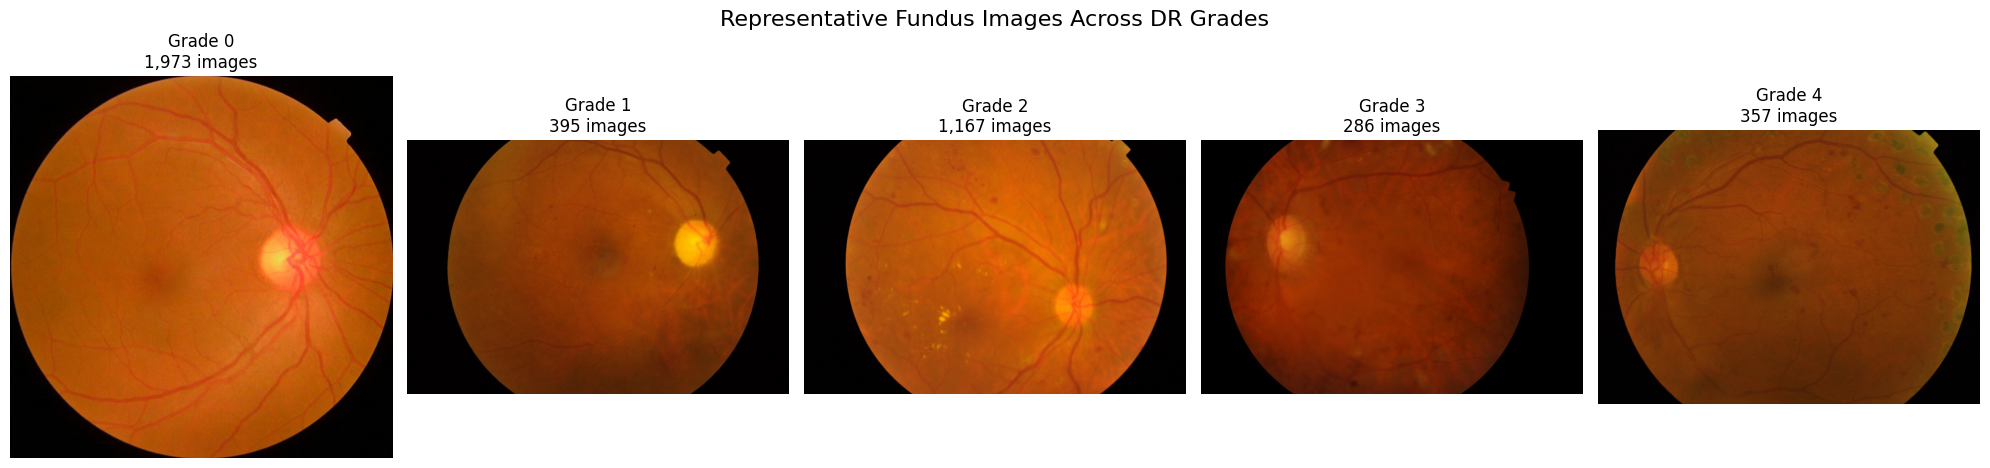


EXACT DUPLICATE IMAGE ANALYSIS
Total records                    : 4,178
Valid images                     : 4,178
Invalid images                   : 0
Unique image hashes              : 4,044
Images involved in exact duplicates: 263

Duplicate images detected:


,id_code,diagnosis,image_path,file_hash
955,aptos_1f07dae3cadb,2,C:\Users\Arnav Sachdeva\Documents\Data\images\...,028d27ff645aaeb21688586fbb0e9299
532,aptos_012a242ac6ff,2,C:\Users\Arnav Sachdeva\Documents\Data\images\...,028d27ff645aaeb21688586fbb0e9299
535,aptos_0161338f53cc,2,C:\Users\Arnav Sachdeva\Documents\Data\images\...,02e855cb5c1eb05c81e6fd027ccdbcf2
3435,aptos_cac40227d3b2,2,C:\Users\Arnav Sachdeva\Documents\Data\images\...,02e855cb5c1eb05c81e6fd027ccdbcf2
938,aptos_1dfbede13143,2,C:\Users\Arnav Sachdeva\Documents\Data\images\...,05f30df45f7e07befe26b995f39cad64
1313,aptos_38fe9f854046,2,C:\Users\Arnav Sachdeva\Documents\Data\images\...,05f30df45f7e07befe26b995f39cad64
3250,aptos_bd5013540a13,4,C:\Users\Arnav Sachdeva\Documents\Data\images\...,0a20d5b84db6d380d9ce66be03b3369c
1003,aptos_22895c89792f,4,C:\Users\Arnav Sachdeva\Documents\Data\images\...,0a20d5b84db6d380d9ce66be03b3369c
2299,aptos_7e160c8b611e,3,C:\Users\Arnav Sachdeva\Documents\Data\images\...,165540476389b5d13f68c4468bcb4ed4
2590,aptos_91b6ebaa3678,3,C:\Users\Arnav Sachdeva\Documents\Data\images\...,165540476389b5d13f68c4468bcb4ed4



FINAL DATASET SUMMARY
Total records       : 4,178
Valid images        : 4,178
Invalid images      : 0
Missing image files : 0
Missing labels      : 0

DR CLASS DISTRIBUTION


,Image Count,Percentage
diagnosis,,
0,1973,47.22
1,395,9.45
2,1167,27.93
3,286,6.85
4,357,8.54



IMAGE COLOR MODES


image_mode
RGB    4178
Name: count, dtype: int64


TOP IMAGE DIMENSIONS


,width,height,Image Count
0,1050,1050,974
1,2416,1736,638
2,4288,2848,568
3,2588,1958,533
4,3216,2136,410
5,2048,1536,351
6,819,614,287
7,3388,2588,141
8,1504,1000,92
9,1844,1226,61


In [39]:
print("=" * 60)
print("REPRESENTATIVE FUNDUS IMAGES")
print("=" * 60)


# ------------------------------------------------------------
# 1. Display one representative image from each DR grade
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    5,
    figsize=(20, 5)
)


for grade in range(5):

    grade_data = df[
        (df[LABEL_COLUMN] == float(grade)) &
        (df["image_valid"])
    ]

    if len(grade_data) == 0:

        axes[grade].set_title(
            f"Grade {grade}\nNo images"
        )

        axes[grade].axis("off")

        continue


    sample = grade_data.sample(
        n=1,
        random_state=SEED
    ).iloc[0]


    image = Image.open(
        sample["image_path"]
    ).convert("RGB")


    axes[grade].imshow(image)

    axes[grade].set_title(
        f"Grade {grade}\n"
        f"{len(grade_data):,} images"
    )

    axes[grade].axis("off")


plt.suptitle(
    "Representative Fundus Images Across DR Grades",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ============================================================
# 2. EXACT DUPLICATE DETECTION
# ============================================================

print("\n" + "=" * 60)
print("EXACT DUPLICATE IMAGE ANALYSIS")
print("=" * 60)


import hashlib


def calculate_md5(path, chunk_size=8192):
    """
    Calculate MD5 hash of an image file.
    Identical files produce identical hashes.
    """

    hash_md5 = hashlib.md5()

    with open(path, "rb") as file:

        for chunk in iter(
            lambda: file.read(chunk_size),
            b""
        ):

            hash_md5.update(chunk)


    return hash_md5.hexdigest()


# ------------------------------------------------------------
# Calculate hashes
# ------------------------------------------------------------

df["file_hash"] = None


valid_indices = df.index[
    df["image_valid"]
]


for index in valid_indices:

    df.loc[index, "file_hash"] = calculate_md5(
        df.loc[index, "image_path"]
    )


# ------------------------------------------------------------
# Find duplicates
# ------------------------------------------------------------

duplicate_mask = (
    df["file_hash"].notna()
    &
    df["file_hash"].duplicated(
        keep=False
    )
)


duplicate_images = (
    df[duplicate_mask]
    .sort_values("file_hash")
)


print(
    f"Total records                    : {len(df):,}"
)

print(
    f"Valid images                     : "
    f"{df['image_valid'].sum():,}"
)

print(
    f"Invalid images                   : "
    f"{(~df['image_valid']).sum():,}"
)

print(
    f"Unique image hashes              : "
    f"{df['file_hash'].nunique():,}"
)

print(
    f"Images involved in exact duplicates: "
    f"{duplicate_mask.sum():,}"
)


if duplicate_mask.sum() > 0:

    print("\nDuplicate images detected:")

    display(
        duplicate_images[
            [
                IMAGE_COLUMN,
                LABEL_COLUMN,
                "image_path",
                "file_hash"
            ]
        ].head(20)
    )

else:

    print("\nNo exact duplicate images detected.")


# ============================================================
# 3. FINAL DATASET SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FINAL DATASET SUMMARY")
print("=" * 60)


print(f"Total records       : {len(df):,}")
print(
    f"Valid images        : "
    f"{df['image_valid'].sum():,}"
)
print(
    f"Invalid images      : "
    f"{(~df['image_valid']).sum():,}"
)
print(
    f"Missing image files : "
    f"{(~df['file_exists']).sum():,}"
)
print(
    f"Missing labels      : "
    f"{df[LABEL_COLUMN].isna().sum():,}"
)


# ------------------------------------------------------------
# DR distribution
# ------------------------------------------------------------

print("\nDR CLASS DISTRIBUTION")

final_class_summary = (
    df[LABEL_COLUMN]
    .value_counts()
    .sort_index()
    .to_frame("Image Count")
)

final_class_summary["Percentage"] = (
    final_class_summary["Image Count"]
    / len(df)
    * 100
).round(2)

display(
    final_class_summary
)


# ------------------------------------------------------------
# Image modes
# ------------------------------------------------------------

print("\nIMAGE COLOR MODES")

display(
    df["image_mode"]
    .value_counts()
)


# ------------------------------------------------------------
# Dimensions
# ------------------------------------------------------------

print("\nTOP IMAGE DIMENSIONS")

display(
    df[
        ["width", "height"]
    ]
    .value_counts()
    .head(10)
    .rename("Image Count")
    .reset_index()
)

In [40]:
print("=" * 60)
print("DUPLICATE LABEL CONSISTENCY ANALYSIS")
print("=" * 60)

# Only consider images that have duplicate hashes
duplicate_groups = (
    df[df["file_hash"].notna()]
    .groupby("file_hash")
    .agg(
        occurrences=(IMAGE_COLUMN, "count"),
        unique_labels=(LABEL_COLUMN, "nunique"),
        labels=(LABEL_COLUMN, lambda x: sorted(x.unique())),
        image_ids=(IMAGE_COLUMN, lambda x: list(x))
    )
)

# Groups where the same image has different labels
conflicting_duplicates = duplicate_groups[
    duplicate_groups["unique_labels"] > 1
]

# Groups where the same image has the same label
consistent_duplicates = duplicate_groups[
    duplicate_groups["unique_labels"] == 1
]

print(f"Duplicate groups              : {len(duplicate_groups):,}")
print(f"Consistent duplicate groups   : {len(consistent_duplicates):,}")
print(f"Conflicting duplicate groups  : {len(conflicting_duplicates):,}")

if len(conflicting_duplicates) > 0:

    print("\n⚠️ CONFLICTING DUPLICATE LABELS FOUND:")

    display(conflicting_duplicates)

else:

    print("\n✅ No conflicting labels found among exact duplicates.")

DUPLICATE LABEL CONSISTENCY ANALYSIS
Duplicate groups              : 4,044
Consistent duplicate groups   : 4,011
Conflicting duplicate groups  : 33

⚠️ CONFLICTING DUPLICATE LABELS FOUND:


,occurrences,unique_labels,labels,image_ids
file_hash,,,,
197303f49434137ed6ab3c9906d76a13,2,2,"[3, 4]","[aptos_14e3f84445f7, aptos_f0f89314e860]"
22f5076c4ee1788e4e80c44b3d459e93,2,2,"[2, 3]","[aptos_3cd801ffdbf0, aptos_7525ebb3434d]"
292a349e96cc5560aeb965019b116180,2,2,"[2, 3]","[aptos_6253f23229b1, aptos_76cfe8967f7d]"
2a613e17fe7eebeca8a21ac5f46e8ec2,2,2,"[2, 4]","[aptos_9e3510963315, aptos_b187b3c93afb]"
2f72ef33ec56843d7425e8c599d73ab1,2,2,"[0, 3]","[train_IDRiD_118, test_IDRiD_064]"
3699552df24b83ecc02d0ce3a397b6e3,2,2,"[1, 2]","[train_IDRiD_021, train_IDRiD_391]"
374fb66d60f97af7ff2c679f81063fbb,2,2,"[2, 4]","[aptos_80964d8e0863, aptos_ab50123abadb]"
3be1e5644df038399c1d31319e733af1,2,2,"[2, 4]","[aptos_9a3c03a5ad0f, aptos_f03d3c4ce7fb]"
6b82af09990c57a676fc03856e4b3400,2,2,"[1, 2]","[aptos_1632c4311fc9, aptos_a75bab2463d4]"


In [41]:
print("=" * 60)
print("CONFLICTING DUPLICATE LABEL DETAILS")
print("=" * 60)

# ------------------------------------------------------------
# Get all conflicting duplicate groups
# ------------------------------------------------------------

conflicting_hashes = conflicting_duplicates.index

conflicting_records = (
    df[df["file_hash"].isin(conflicting_hashes)]
    .sort_values(["file_hash", LABEL_COLUMN])
)

# ------------------------------------------------------------
# Add source information
# ------------------------------------------------------------

if "source" not in df.columns:
    df["source"] = np.where(
        df[IMAGE_COLUMN].astype(str).str.startswith("aptos_"),
        "APTOS",
        np.where(
            df[IMAGE_COLUMN].astype(str).str.startswith("train_IDRiD_"),
            "IDRiD",
            "OTHER"
        )
    )

# ------------------------------------------------------------
# Display all conflicting records
# ------------------------------------------------------------

display(
    conflicting_records[
        [
            IMAGE_COLUMN,
            LABEL_COLUMN,
            "source",
            "image_path",
            "file_hash"
        ]
    ]
)

CONFLICTING DUPLICATE LABEL DETAILS


,id_code,diagnosis,source,image_path,file_hash
789,aptos_14e3f84445f7,3,APTOS,C:\Users\Arnav Sachdeva\Documents\Data\images\...,197303f49434137ed6ab3c9906d76a13
3990,aptos_f0f89314e860,4,APTOS,C:\Users\Arnav Sachdeva\Documents\Data\images\...,197303f49434137ed6ab3c9906d76a13
1363,aptos_3cd801ffdbf0,2,APTOS,C:\Users\Arnav Sachdeva\Documents\Data\images\...,22f5076c4ee1788e4e80c44b3d459e93
2167,aptos_7525ebb3434d,3,APTOS,C:\Users\Arnav Sachdeva\Documents\Data\images\...,22f5076c4ee1788e4e80c44b3d459e93
2196,aptos_76cfe8967f7d,2,APTOS,C:\Users\Arnav Sachdeva\Documents\Data\images\...,292a349e96cc5560aeb965019b116180
...,...,...,...,...,...
3868,aptos_e8d1c6c07cf2,3,APTOS,C:\Users\Arnav Sachdeva\Documents\Data\images\...,f2925812dee45e7dba0ca4fbb346ea99
2687,aptos_98f7136d2e7a,2,APTOS,C:\Users\Arnav Sachdeva\Documents\Data\images\...,f52144fec260494290f0ba7b23653c02
3848,aptos_e740af6ac6ea,4,APTOS,C:\Users\Arnav Sachdeva\Documents\Data\images\...,f52144fec260494290f0ba7b23653c02
4134,aptos_fcc6aa6755e6,3,APTOS,C:\Users\Arnav Sachdeva\Documents\Data\images\...,fc193ee5b4467caaeeb4cbb68d442535


In [42]:
print("=" * 60)
print("CONFLICTING DUPLICATE SOURCE ANALYSIS")
print("=" * 60)

conflict_source_summary = (
    conflicting_records
    .groupby(["file_hash", "source"])[LABEL_COLUMN]
    .agg(
        labels=lambda x: sorted(x.unique()),
        count="count"
    )
    .reset_index()
)

display(conflict_source_summary)

CONFLICTING DUPLICATE SOURCE ANALYSIS


,file_hash,source,labels,count
0,197303f49434137ed6ab3c9906d76a13,APTOS,"[3, 4]",2
1,22f5076c4ee1788e4e80c44b3d459e93,APTOS,"[2, 3]",2
2,292a349e96cc5560aeb965019b116180,APTOS,"[2, 3]",2
3,2a613e17fe7eebeca8a21ac5f46e8ec2,APTOS,"[2, 4]",2
4,2f72ef33ec56843d7425e8c599d73ab1,IDRiD,[0],1
5,2f72ef33ec56843d7425e8c599d73ab1,OTHER,[3],1
6,3699552df24b83ecc02d0ce3a397b6e3,IDRiD,"[1, 2]",2
7,374fb66d60f97af7ff2c679f81063fbb,APTOS,"[2, 4]",2
8,3be1e5644df038399c1d31319e733af1,APTOS,"[2, 4]",2
9,6b82af09990c57a676fc03856e4b3400,APTOS,"[1, 2]",2


In [43]:
print("=" * 60)
print("CONFLICTING LABEL PAIRS")
print("=" * 60)

label_pairs = []

for file_hash, group in conflicting_records.groupby("file_hash"):

    labels = sorted(group[LABEL_COLUMN].unique())

    label_pairs.append({
        "file_hash": file_hash,
        "labels": " vs ".join(map(str, labels)),
        "number_of_records": len(group)
    })

conflict_pairs_df = pd.DataFrame(label_pairs)

display(
    conflict_pairs_df["labels"]
    .value_counts()
    .rename("Number of Duplicate Groups")
    .reset_index()
)

CONFLICTING LABEL PAIRS


,labels,Number of Duplicate Groups
0,2 vs 3,9
1,2 vs 4,8
2,1 vs 2,6
3,3 vs 4,4
4,0 vs 1,4
5,0 vs 3,1
6,1 vs 4,1


In [44]:
print("=" * 70)
print("FINAL DATASET CLEANING")
print("=" * 70)

import shutil
from datetime import datetime


# ============================================================
# 1. BACKUP ORIGINAL CSV
# ============================================================

csv_path = CSV_PATH

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

backup_path = csv_path.with_name(
    f"{csv_path.stem}_BACKUP_{timestamp}{csv_path.suffix}"
)

shutil.copy2(csv_path, backup_path)

print(f"Original CSV backed up to:")
print(backup_path)


# ============================================================
# 2. IDENTIFY CONFLICTING DUPLICATE GROUPS
# ============================================================

conflicting_hashes = set(
    conflicting_duplicates.index
)

conflicting_rows = df[
    df["file_hash"].isin(conflicting_hashes)
].copy()


print("\n" + "=" * 70)
print("CONFLICTING DUPLICATES")
print("=" * 70)

print(
    f"Conflicting duplicate groups : "
    f"{len(conflicting_hashes):,}"
)

print(
    f"Records belonging to them    : "
    f"{len(conflicting_rows):,}"
)


# ============================================================
# 3. REMOVE ALL CONFLICTING DUPLICATE RECORDS
# ============================================================

df_clean = df[
    ~df["file_hash"].isin(conflicting_hashes)
].copy()


# ============================================================
# 4. REMOVE REDUNDANT SAME-LABEL DUPLICATES
# ============================================================

# After removing conflicting groups, identical images that have
# the same label are safe to reduce to one copy.

duplicate_mask = (
    df_clean["file_hash"].notna()
    &
    df_clean["file_hash"].duplicated(
        keep="first"
    )
)

duplicate_rows_to_remove = df_clean[
    duplicate_mask
].copy()


print("\n" + "=" * 70)
print("REDUNDANT SAME-LABEL DUPLICATES")
print("=" * 70)

print(
    f"Redundant duplicate records : "
    f"{len(duplicate_rows_to_remove):,}"
)


# Keep the first occurrence of every identical image
df_clean = df_clean[
    ~duplicate_mask
].copy()


# ============================================================
# 5. DETERMINE ALL IMAGE FILES TO DELETE
# ============================================================

files_to_delete = []

for _, row in conflicting_rows.iterrows():

    path = Path(row["image_path"])

    if path.exists():
        files_to_delete.append(path)


for _, row in duplicate_rows_to_remove.iterrows():

    path = Path(row["image_path"])

    if path.exists():
        files_to_delete.append(path)


# Remove accidental duplicate paths
files_to_delete = list(
    dict.fromkeys(files_to_delete)
)


print("\n" + "=" * 70)
print("FILES TO DELETE")
print("=" * 70)

print(
    f"Total image files to delete : "
    f"{len(files_to_delete):,}"
)


# ============================================================
# 6. DELETE REDUNDANT / CONFLICTING IMAGE FILES
# ============================================================

deleted_count = 0

for path in files_to_delete:

    try:

        path.unlink()
        deleted_count += 1

    except Exception as error:

        print(
            f"Could not delete {path.name}: {error}"
        )


print(
    f"Successfully deleted        : "
    f"{deleted_count:,}"
)


# ============================================================
# 7. REMOVE HELPER COLUMNS BEFORE SAVING CSV
# ============================================================

columns_to_remove = [
    "image_path",
    "file_exists",
    "image_valid",
    "width",
    "height",
    "image_mode",
    "file_hash",
    "source"
]

df_clean_csv = df_clean.drop(
    columns=[
        column
        for column in columns_to_remove
        if column in df_clean.columns
    ]
)


# ============================================================
# 8. SAVE CLEANED CSV TO ORIGINAL LOCATION
# ============================================================

df_clean_csv.to_csv(
    csv_path,
    index=False
)


# ============================================================
# 9. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("CLEANING COMPLETE")
print("=" * 70)

print(
    f"Original records : {len(df):,}"
)

print(
    f"Clean records    : {len(df_clean):,}"
)

print(
    f"Records removed  : "
    f"{len(df) - len(df_clean):,}"
)

print(
    f"Images deleted   : "
    f"{deleted_count:,}"
)

print(
    f"Remaining images : "
    f"{len(list(DATASET_DIR.iterdir())):,}"
)

print(
    f"Clean CSV saved  : "
    f"{csv_path}"
)


print("\nFinal class distribution:")

display(
    df_clean_csv[LABEL_COLUMN]
    .value_counts()
    .sort_index()
)

FINAL DATASET CLEANING
Original CSV backed up to:
C:\Users\Arnav Sachdeva\Documents\Data\labels_BACKUP_20260903_184729.csv

CONFLICTING DUPLICATES
Conflicting duplicate groups : 33
Records belonging to them    : 68

REDUNDANT SAME-LABEL DUPLICATES
Redundant duplicate records : 99

FILES TO DELETE
Total image files to delete : 167
Successfully deleted        : 167

CLEANING COMPLETE
Original records : 4,178
Clean records    : 4,011
Records removed  : 167
Images deleted   : 167
Remaining images : 4,011
Clean CSV saved  : C:\Users\Arnav Sachdeva\Documents\Data\labels.csv

Final class distribution:


diagnosis
0    1963
1     361
2    1087
3     268
4     332
Name: count, dtype: int64

In [45]:
print("=" * 70)
print("FINAL DATASET DUPLICATE & CONFLICT VERIFICATION")
print("=" * 70)

import hashlib
from collections import defaultdict


# ============================================================
# 1. CALCULATE HASHES FOR ALL REMAINING IMAGES
# ============================================================

def calculate_md5(path, chunk_size=8192):
    hash_md5 = hashlib.md5()

    with open(path, "rb") as file:
        for chunk in iter(lambda: file.read(chunk_size), b""):
            hash_md5.update(chunk)

    return hash_md5.hexdigest()


# Rebuild image lookup from the CLEANED image folder
remaining_image_files = [
    p for p in DATASET_DIR.iterdir()
    if p.is_file()
]

image_lookup_clean = {
    p.stem: p
    for p in remaining_image_files
}


# Load the cleaned CSV again
df_final = pd.read_csv(CSV_PATH)

df_final["image_path"] = (
    df_final[IMAGE_COLUMN]
    .astype(str)
    .map(image_lookup_clean)
)

df_final["file_exists"] = df_final["image_path"].notna()


# ============================================================
# 2. BASIC INTEGRITY CHECK
# ============================================================

print("\n" + "=" * 70)
print("DATASET INTEGRITY")
print("=" * 70)

print(f"CSV records          : {len(df_final):,}")
print(f"Image files          : {len(remaining_image_files):,}")
print(f"Matched images       : {df_final['file_exists'].sum():,}")
print(
    f"Missing image files  : "
    f"{(~df_final['file_exists']).sum():,}"
)
print(
    f"Missing labels       : "
    f"{df_final[LABEL_COLUMN].isna().sum():,}"
)


# ============================================================
# 3. CALCULATE IMAGE HASHES
# ============================================================

df_final["file_hash"] = None

for index, row in df_final.iterrows():

    path = row["image_path"]

    if path is not None and Path(path).exists():

        df_final.loc[index, "file_hash"] = calculate_md5(path)


# ============================================================
# 4. EXACT DUPLICATE CHECK
# ============================================================

duplicate_mask = (
    df_final["file_hash"].notna()
    &
    df_final["file_hash"].duplicated(keep=False)
)

duplicate_records = df_final[duplicate_mask].copy()


print("\n" + "=" * 70)
print("EXACT DUPLICATE CHECK")
print("=" * 70)

print(
    f"Unique image hashes : "
    f"{df_final['file_hash'].nunique():,}"
)

print(
    f"Duplicate records   : "
    f"{len(duplicate_records):,}"
)


# ============================================================
# 5. CHECK WHETHER ANY DUPLICATES HAVE CONFLICTING LABELS
# ============================================================

if len(duplicate_records) > 0:

    duplicate_groups = (
        duplicate_records
        .groupby("file_hash")[LABEL_COLUMN]
        .nunique()
    )

    conflicting_groups = duplicate_groups[
        duplicate_groups > 1
    ]

else:

    conflicting_groups = pd.Series(dtype=int)


print("\n" + "=" * 70)
print("CONFLICTING LABEL CHECK")
print("=" * 70)

print(
    f"Conflicting duplicate groups : "
    f"{len(conflicting_groups):,}"
)


# ============================================================
# 6. FINAL VERDICT
# ============================================================

print("\n" + "=" * 70)
print("FINAL VERDICT")
print("=" * 70)


if (
    df_final[LABEL_COLUMN].isna().sum() == 0
    and
    (~df_final["file_exists"]).sum() == 0
    and
    len(duplicate_records) == 0
    and
    len(conflicting_groups) == 0
):

    print("✅ DATASET IS CLEAN")
    print("✅ No missing labels")
    print("✅ No missing image files")
    print("✅ No exact duplicate images")
    print("✅ No conflicting duplicate labels")
    print("✅ Ready for preprocessing and model training")

else:

    print("⚠️ DATASET STILL HAS ISSUES")

    if df_final[LABEL_COLUMN].isna().sum() > 0:
        print("❌ Missing labels detected")

    if (~df_final["file_exists"]).sum() > 0:
        print("❌ Missing image files detected")

    if len(duplicate_records) > 0:
        print("❌ Exact duplicate images detected")

    if len(conflicting_groups) > 0:
        print("❌ Conflicting duplicate labels detected")

FINAL DATASET DUPLICATE & CONFLICT VERIFICATION

DATASET INTEGRITY
CSV records          : 4,011
Image files          : 4,011
Matched images       : 4,011
Missing image files  : 0
Missing labels       : 0

EXACT DUPLICATE CHECK
Unique image hashes : 4,011
Duplicate records   : 0

CONFLICTING LABEL CHECK
Conflicting duplicate groups : 0

FINAL VERDICT
✅ DATASET IS CLEAN
✅ No missing labels
✅ No missing image files
✅ No exact duplicate images
✅ No conflicting duplicate labels
✅ Ready for preprocessing and model training


In [46]:
# Cell 19 — Load final cleaned dataframe and resolve image paths

from pathlib import Path
import pandas as pd

# --------------------------------------------------
# Configurable paths
# --------------------------------------------------

CSV_PATH = Path(r"C:\Users\Arnav Sachdeva\Documents\Data\labels.csv")
DATASET_DIR = Path(r"C:\Users\Arnav Sachdeva\Documents\Data\images")

IMAGE_COLUMN = "id_code"
LABEL_COLUMN = "diagnosis"

# --------------------------------------------------
# Load final cleaned CSV
# --------------------------------------------------

df = pd.read_csv(CSV_PATH)

print("DataFrame shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# --------------------------------------------------
# Resolve image paths
# --------------------------------------------------

image_extensions = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

# Create a lookup: filename stem -> full image path
image_lookup = {
    image_path.stem: image_path
    for image_path in DATASET_DIR.iterdir()
    if image_path.is_file() and image_path.suffix in image_extensions
}

df["image_path"] = df[IMAGE_COLUMN].map(image_lookup)

# --------------------------------------------------
# Basic verification
# --------------------------------------------------

print("\nImages found:", df["image_path"].notna().sum())
print("Images missing:", df["image_path"].isna().sum())

print("\nClass distribution:")
print(df[LABEL_COLUMN].value_counts().sort_index())

print("\nFirst 5 rows:")
print(df[[IMAGE_COLUMN, LABEL_COLUMN, "image_path"]].head())

DataFrame shape: (4011, 2)

Columns: ['id_code', 'diagnosis']

Images found: 4011
Images missing: 0

Class distribution:
diagnosis
0    1963
1     361
2    1087
3     268
4     332
Name: count, dtype: int64

First 5 rows:
           id_code  diagnosis  \
0  train_IDRiD_001          3   
1  train_IDRiD_002          3   
2  train_IDRiD_003          2   
3  train_IDRiD_004          3   
4  train_IDRiD_005          4   

                                          image_path  
0  C:\Users\Arnav Sachdeva\Documents\Data\images\...  
1  C:\Users\Arnav Sachdeva\Documents\Data\images\...  
2  C:\Users\Arnav Sachdeva\Documents\Data\images\...  
3  C:\Users\Arnav Sachdeva\Documents\Data\images\...  
4  C:\Users\Arnav Sachdeva\Documents\Data\images\...  


In [47]:
# Cell 20 — Dataset source, image format, and class distribution analysis

from collections import Counter

# --------------------------------------------------
# 1. Identify dataset source from image ID
# --------------------------------------------------

def identify_source(image_id):
    image_id = str(image_id).upper()

    if "IDRID" in image_id:
        return "IDRiD"
    elif "APTOS" in image_id:
        return "APTOS"
    else:
        return "OTHER"


df["dataset_source"] = df[IMAGE_COLUMN].apply(identify_source)

# --------------------------------------------------
# 2. Identify image file extension
# --------------------------------------------------

df["image_extension"] = df["image_path"].apply(
    lambda x: x.suffix.lower()
)

# --------------------------------------------------
# 3. Dataset source counts
# --------------------------------------------------

print("=" * 50)
print("DATASET SOURCE COUNTS")
print("=" * 50)

source_counts = df["dataset_source"].value_counts()

print(source_counts)

print("\nTotal:", source_counts.sum())

# --------------------------------------------------
# 4. Image format counts
# --------------------------------------------------

print("\n" + "=" * 50)
print("IMAGE FORMAT COUNTS")
print("=" * 50)

extension_counts = df["image_extension"].value_counts()

print(extension_counts)

# --------------------------------------------------
# 5. Overall class distribution
# --------------------------------------------------

print("\n" + "=" * 50)
print("OVERALL CLASS DISTRIBUTION")
print("=" * 50)

class_counts = df[LABEL_COLUMN].value_counts().sort_index()

for grade, count in class_counts.items():
    percentage = (count / len(df)) * 100
    print(f"Grade {grade}: {count:4d} images ({percentage:6.2f}%)")

# --------------------------------------------------
# 6. Class distribution by dataset source
# --------------------------------------------------

print("\n" + "=" * 50)
print("CLASS DISTRIBUTION BY DATASET SOURCE")
print("=" * 50)

source_class_counts = pd.crosstab(
    df["dataset_source"],
    df[LABEL_COLUMN]
)

# Ensure all grades 0–4 are displayed
source_class_counts = source_class_counts.reindex(
    columns=[0, 1, 2, 3, 4],
    fill_value=0
)

print(source_class_counts)

# --------------------------------------------------
# 7. Percentage distribution within each source
# --------------------------------------------------

print("\n" + "=" * 50)
print("CLASS PERCENTAGE WITHIN EACH DATASET SOURCE")
print("=" * 50)

source_class_percent = (
    source_class_counts
    .div(source_class_counts.sum(axis=1), axis=0)
    * 100
)

print(source_class_percent.round(2))

# --------------------------------------------------
# 8. Check for unexpected image extensions
# --------------------------------------------------

known_extensions = {".jpg", ".jpeg", ".png"}

unexpected_extensions = df.loc[
    ~df["image_extension"].isin(known_extensions),
    "image_extension"
].value_counts()

print("\n" + "=" * 50)
print("OTHER / UNEXPECTED IMAGE TYPES")
print("=" * 50)

if len(unexpected_extensions) == 0:
    print("No unexpected image formats found.")
else:
    print(unexpected_extensions)

DATASET SOURCE COUNTS
dataset_source
APTOS    3504
IDRiD     507
Name: count, dtype: int64

Total: 4011

IMAGE FORMAT COUNTS
image_extension
.png    3504
.jpg     507
Name: count, dtype: int64

OVERALL CLASS DISTRIBUTION
Grade 0: 1963 images ( 48.94%)
Grade 1:  361 images (  9.00%)
Grade 2: 1087 images ( 27.10%)
Grade 3:  268 images (  6.68%)
Grade 4:  332 images (  8.28%)

CLASS DISTRIBUTION BY DATASET SOURCE
diagnosis          0    1    2    3    4
dataset_source                          
APTOS           1796  338  922  177  271
IDRiD            167   23  165   91   61

CLASS PERCENTAGE WITHIN EACH DATASET SOURCE
diagnosis           0     1      2      3      4
dataset_source                                  
APTOS           51.26  9.65  26.31   5.05   7.73
IDRiD           32.94  4.54  32.54  17.95  12.03

OTHER / UNEXPECTED IMAGE TYPES
No unexpected image formats found.
